## Assignment 01 - EN3160
### Fernando H.M.D. - 230180F

Question 01

In [161]:
# Intensity transformation functions
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q1.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [162]:
def intensity_transform(im, breakpoints):

    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    im_float = im.astype(np.float32)
    transformed = np.zeros_like(im_float)

    # Piecewise linear interpolation
    lut = np.zeros(256, dtype=np.float32)

    intensity_values = np.arange(256, dtype=np.float32)

    # Process each pair of consecutive breakpoints
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x1 == x2:
            continue

        # Intensities lying on this segment
        mask = (
            (intensity_values >= x1) &
            (intensity_values <= x2)
        )

        lut[mask] = (
            y1
            + (y2 - y1) *
            (intensity_values[mask] - x1) /
            (x2 - x1)
        )
        
    # At repeated x-values, use the value AFTER the jump
    for i in range(len(breakpoints) - 1):
        if x[i] == x[i + 1]:
            jump_x = int(x[i])
            lut[jump_x] = y[i + 1]

    lut = np.clip(lut, 0, 255).astype(np.uint8)

    return lut[im]


In [163]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [200, 200],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)


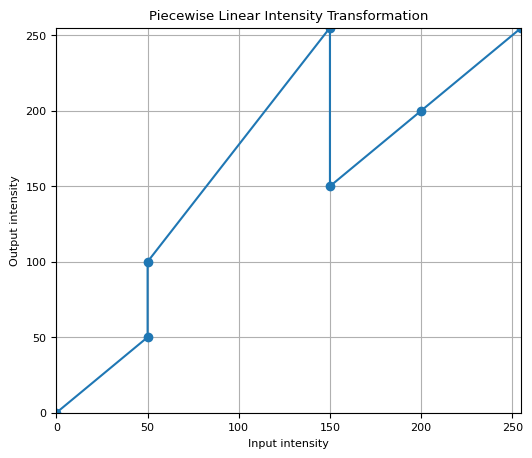

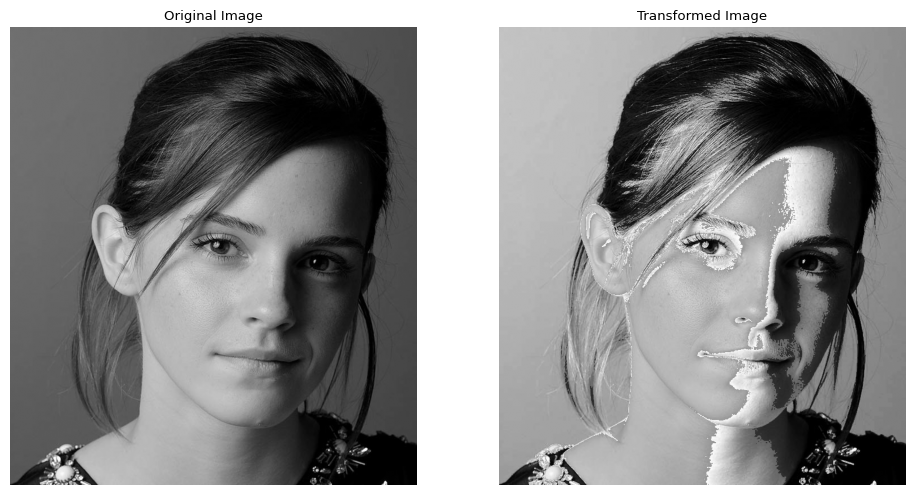

In [164]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

For a visually pleasing output

In [165]:

breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 100],
    [150, 150],
    [255, 255]
])

transformed = intensity_transform(img, breakpoints)

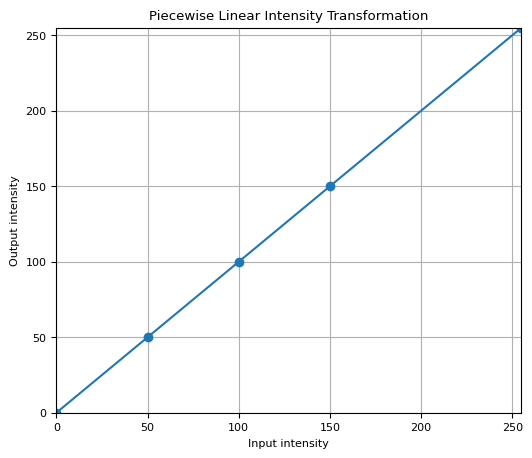

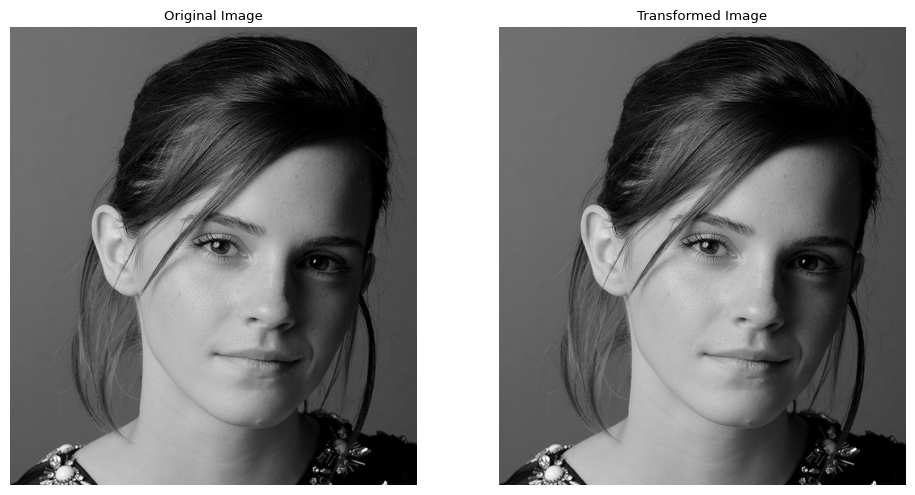

In [166]:
plt.figure(figsize=(6, 5))

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    marker='o'
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Question 2

In [167]:
img = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q2.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

print("image shape", img.shape)

image shape (217, 181)


White matter and Gray matter in a brain proton density image does not mean the places with high pixel intensities and lower areas. rather, White and Gray matter means seperate areas of tissue.

To find the pixel intensities of the designated areas, we can inspect biological areas of white and gray matter. We can inspect that the gray matter is in the region of Y[80:90], X[30:40]... the wrinkly outer tissue of the brain. And the white matter is roughly Y[100:120] X[50:70] region. The white range in the middle is not white matter. that is CSF region.

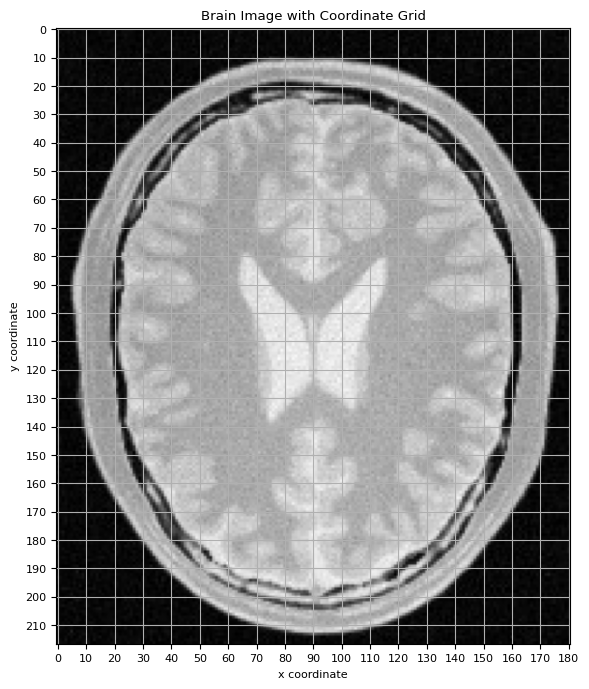

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(img, cmap="gray", vmin=0, vmax=255)

plt.xticks(range(0, img.shape[1], 10))
plt.yticks(range(0, img.shape[0], 10))

plt.grid(True)

plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.title("Brain Image with Coordinate Grid")

plt.show()

In [169]:
white_roi = img[100:120, 50:60]

print("White matter mean:", np.mean(white_roi))
print("White matter min :", np.min(white_roi))
print("White matter max :", np.max(white_roi))

gray_roi = img[150:160, 40:50]

print("Gray matter mean:", np.mean(gray_roi))
print("Gray matter min :", np.min(gray_roi))
print("Gray matter max :", np.max(gray_roi))

White matter mean: 167.21
White matter min : 148
White matter max : 194
Gray matter mean: 196.85
Gray matter min : 171
Gray matter max : 222


Now, I am using Gaussian pulse as the intensity transformation function to accentuate only the required range of pixel intensities. The reason to use Gaussian pulse rather than block pixels is to remove the jump discontinuities and obtain a smooth contrast from the rest of the image. The white matter is centered arounf 167.21 ~ 165 and gray matter is centered arounf 196.85 ~ 200. Such is the value of miu. As for sigma, sigma reflects the range of values that will be accentuated.

In [170]:
def gaussian_intensity_transform(im, mu, sigma):
    x = np.arange(256)

    # Create transformation
    T = 255 * np.exp(
        -((x - mu) ** 2) / (2 * sigma ** 2)
    )

    T = np.clip(T, 0, 255).astype(np.uint8)

    # Apply lookup table to image
    transformed = T[im]

    return transformed, T

In [171]:
white_matter, T_white = gaussian_intensity_transform(
    img, mu=165, sigma=15
)

gray_matter, T_gray = gaussian_intensity_transform(
    img, mu=200, sigma=15
)

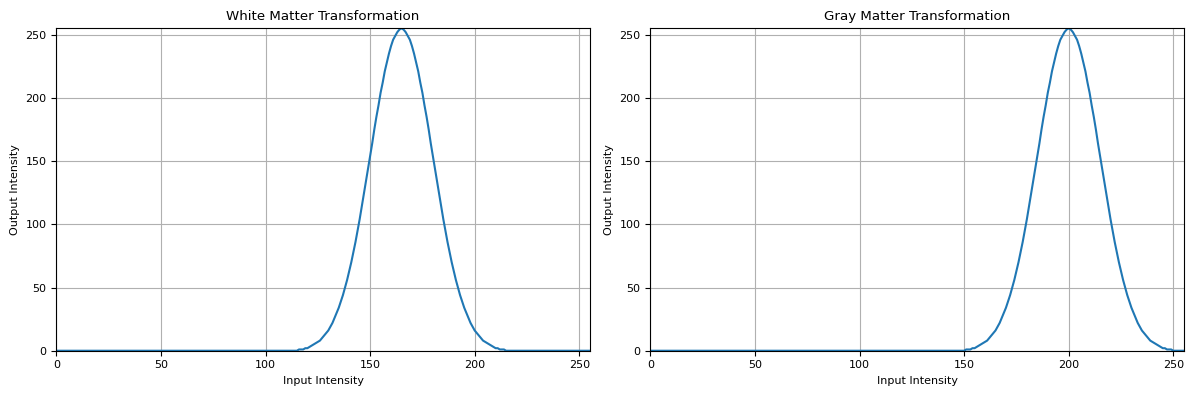

In [172]:
x = np.arange(256)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, T_white)
axes[0].set_title("White Matter Transformation")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].grid()

axes[1].plot(x, T_gray)
axes[1].set_title("Gray Matter Transformation")
axes[1].set_xlabel("Input Intensity")
axes[1].set_ylabel("Output Intensity")
axes[1].set_xlim(0, 255)
axes[1].set_ylim(0, 255)
axes[1].grid()

plt.tight_layout()
plt.show()

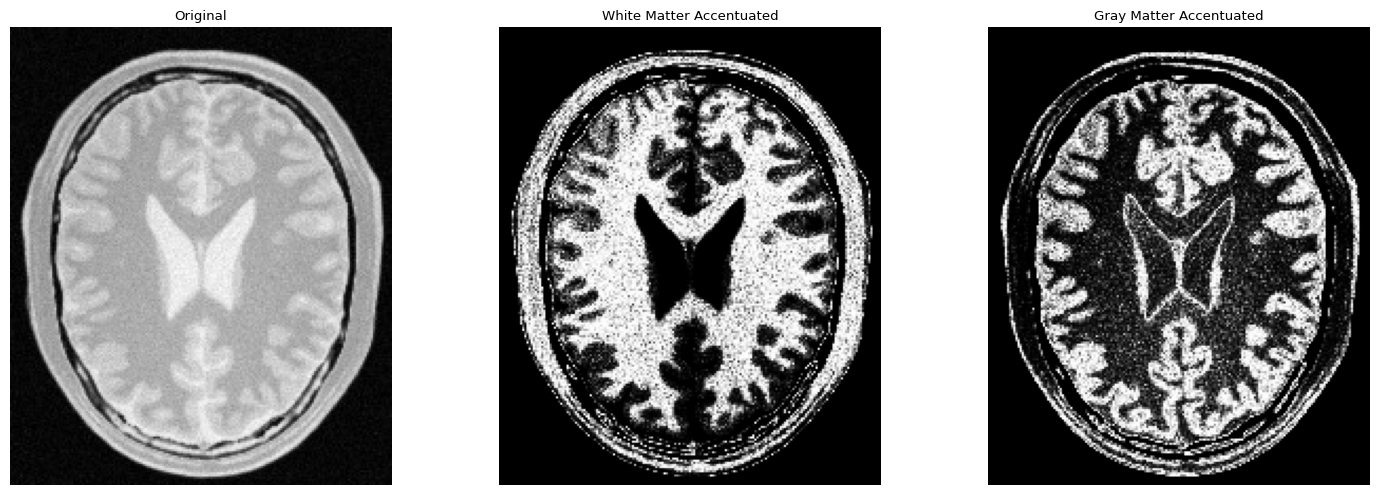

In [173]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(white_matter, cmap="gray")
axes[1].set_title("White Matter Accentuated")

axes[2].imshow(gray_matter, cmap="gray")
axes[2].set_title("Gray Matter Accentuated")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Question 03

In this question, we talk about L* a* b* colour images. 
In an RGB image, the brightness of the image is not an attribute that i controlled by just R, g or B, but by the combination of all three. So, doing a gamma correction on an RGB image can alter the colours of the image. A way to prevent this is to, apply gamma correction in the Lab plane. In Lab plane, the image is segragrated to 
$$L∗ =lightness $$
$$ a^* = \text{green} \leftrightarrow \text{red} $$
$$ b∗=blue↔yellow $$
Then we apply gamma to the L* plane.

In [174]:
img3 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q3.jpeg")

if img is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [175]:
img3_lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
L, a, b = cv2.split(img3_lab)

In [176]:
# Applying gamma correction to the L place. 
gamma = 0.8
lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

L_modified = cv2.LUT(L, lut)

# Merge back and convert to BGR
corrected_lab = cv2.merge([L_modified, a, b])
corrected_bgr = cv2.cvtColor(corrected_lab, cv2.COLOR_LAB2BGR)
corrected_rgb = cv2.cvtColor(corrected_lab, cv2.COLOR_LAB2RGB)

(np.float64(-0.5), np.float64(719.5), np.float64(479.5), np.float64(-0.5))

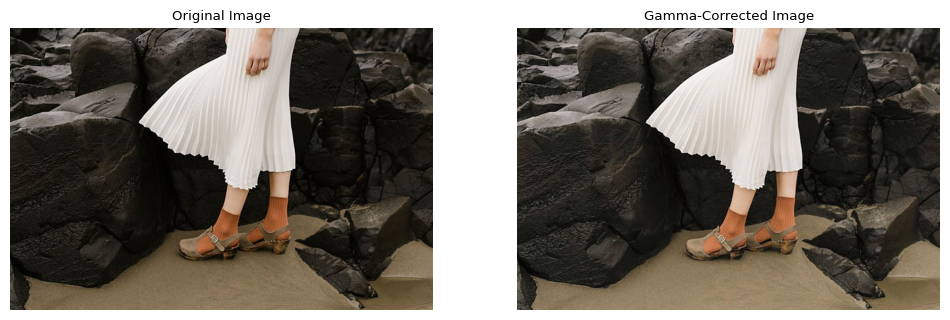

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
colors = ('r', 'g', 'b')

# --- Row 1: Images ---
axes[0].imshow(img3_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(corrected_rgb)
axes[1].set_title("Gamma-Corrected Image")
axes[1].axis("off")

The gamma correction has made the darker areas specially the rock, more detailed and less shadowy. 

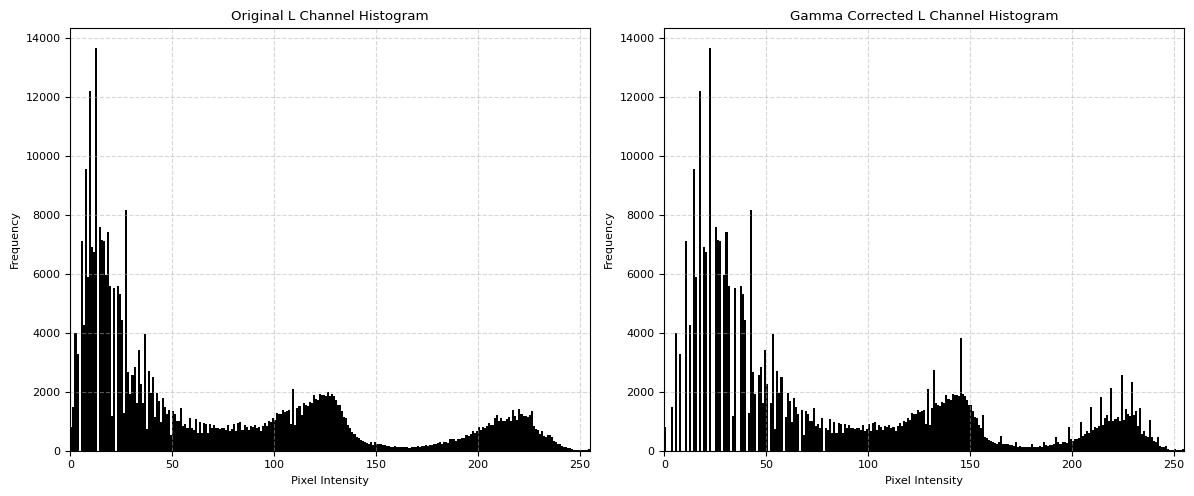

In [178]:
#Histograms of L
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(L.ravel(), bins=256, range=[0, 256], color='black')
axes[0].set_title("Original L Channel Histogram")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 255)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gamma Corrected L Histogram
axes[1].hist(L_modified.ravel(), bins=256, range=[0, 256], color='black')
axes[1].set_title("Gamma Corrected L Channel Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

We can clearly see the effect of the gamma correction in the second histogram, where the low intensity pixels are mapped into a ligheter range. That is, the darker areas are lightened. 

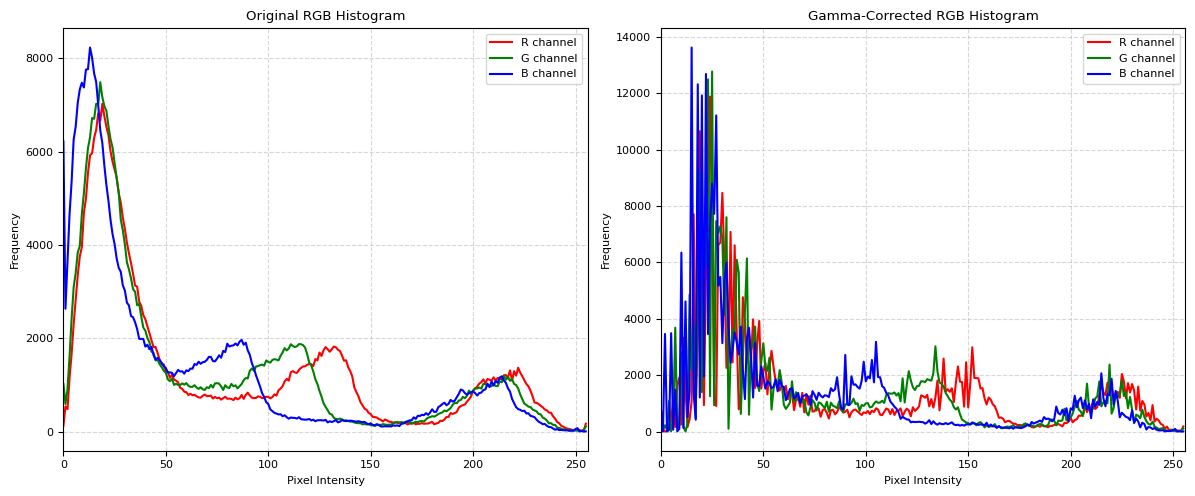

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original Image RGB Histogram

for i, col in enumerate(colors):
    hist = cv2.calcHist([img3_rgb], [i], None, [256], [0, 256])
    axes[0].plot(hist, color=col, label=f"{col.upper()} channel")

axes[0].set_title("Original RGB Histogram")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim([0, 256])
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Corrected Image RGB Histogram
for i, col in enumerate(colors):
    hist = cv2.calcHist([corrected_rgb], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=col, label=f"{col.upper()} channel")

axes[1].set_title("Gamma-Corrected RGB Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Interpretation of results:
Gamma correction is a nonlinear transformation. It is going to transform the L and the RGB planes non linearly. This accounts for the noisy like histograms.

Question 04

In this question, we split the image into, Hue, Saturation and Value/ Brightness planes. Instead of directly chandinng the value of brightness, we apply a gaussian smoothing function centered around 128, with a variance of 70 to the Saturation plane. 

Saturation has higher values for high colour areas ex: the spider man suit, zendaya hair where as lower values for less colourfull areas ex: buildings. Thus, applying the transformatio to the saturation plane,enhances the visibility of colours that is, makes the image look more colourful/vivid.

In [180]:
img4 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q4.jpeg", cv2.IMREAD_COLOR_RGB)

if img4 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

In [181]:
# Splitting into Saturation, Hue and Value planes
img4_HSV = cv2.cvtColor(img4, cv2.COLOR_RGB2HSV)

H, S, V = cv2.split(img4_HSV)

The value of \(a\) determines the strength of the vibrance enhancement applied to the saturation plane. When \(a=0\), the transformation reduces to the identity transformation. As \(a\) increases, the saturation of the image increases, making the existing colours appear more vivid while preserving their hue.

In [182]:
def intensity_transform(x, a, sigma):
    x = np.array(x, dtype=np.float64)
    
    gaussian_term = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma ** 2)))
    transformed = x + gaussian_term
    
    result = np.minimum(transformed, 255.0)
    
    return np.round(result).astype(np.uint8)

# Apply the transformation to the Saturation channel
saturated_image = intensity_transform(S, a=0.65, sigma=70)

corrected_hsv = cv2.merge([H, saturated_image, V])
corrected_rgb = cv2.cvtColor(corrected_hsv, cv2.COLOR_HSV2RGB)

After careful tryouts $$a=0.65$$ was selected as the best vlue for the image to look visually pleasing without having extreme colour contrasts.

In the image, it can be seen that the red colour of the suit and orange of hair are more highlighted than the original image. This is the difference done by the transformation.

(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

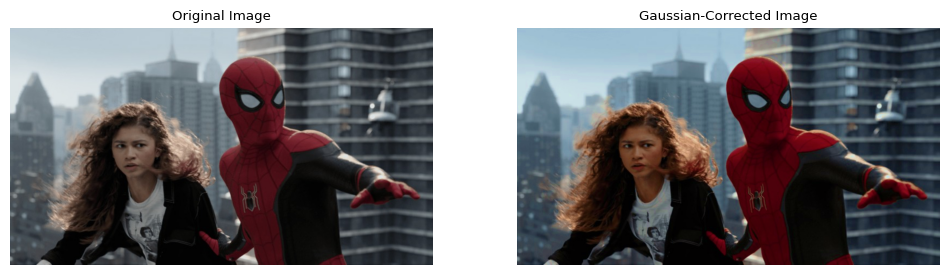

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# --- Row 1: Images ---
axes[0].imshow(img4)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(corrected_rgb)
axes[1].set_title("Gaussian-Corrected Image")
axes[1].axis("off")

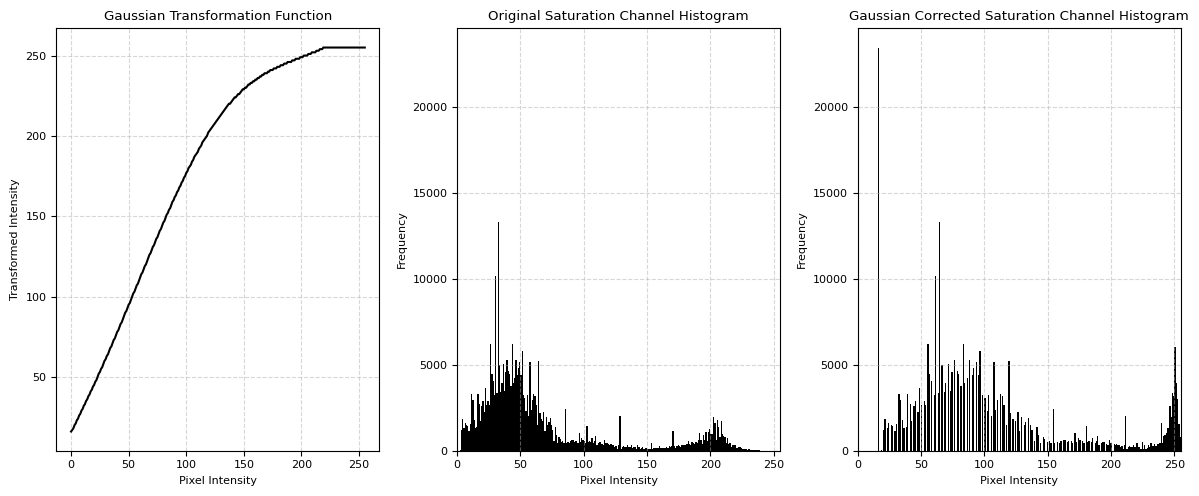

In [184]:
#Histograms of Saturation
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# gaussian transformation plot
axes[0].plot(np.arange(256), intensity_transform(np.arange(256), a=0.65, sigma=70), color='black')
axes[0].set_title("Gaussian Transformation Function")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Transformed Intensity")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(S.ravel(), bins=256, range=[0, 256], color='black')
axes[1].set_title("Original Saturation Channel Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Gaussian Corrected Saturation Histogram
axes[2].hist(saturated_image.ravel(), bins=256, range=[0, 256], color='black')
axes[2].set_title("Gaussian Corrected Saturation Channel Histogram")
axes[2].set_xlabel("Pixel Intensity")
axes[2].set_ylabel("Frequency")
axes[2].set_xlim(0, 255)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Question 05

In [191]:
img5 = cv2.imread(r"C:\Users\minay\Desktop\ENTC\ACA\Semester 5\EN3160 - Image Processing and Machine Vision\Assignment\EN3160\Assignment 1\images\q5.tif", cv2.IMREAD_GRAYSCALE)

if img5 is None:
    raise FileNotFoundError("Image could not be loaded. Check the file path.")

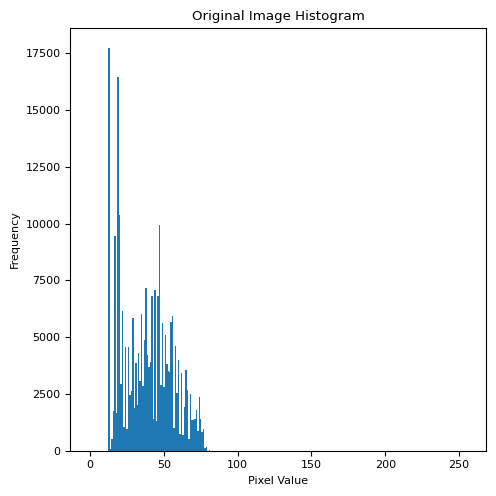

In [203]:
# get the histogram of the original image
hist, bins = np.histogram(img5.flatten(), 256, [0, 256])

fig, axes = plt.subplots(1, 1, figsize=(5, 5))
plt.bar(x, hist, width=1)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Original Image Histogram')
plt.tight_layout()
plt.show()

We can see that the image has more pixels in the range of low pixel values.
Now let us apply histogram equalization.
\begin{equation}
s_k = T(r_k) = \frac{L-1}{MN} \sum_{j=0}^{k} n_j
\end{equation}

In [211]:
# Histogram Equalization using the equation

# Compute the cumulative distribution function (CDF)
def histogram_equalization(img):

    hist = np.zeros(256, dtype=np.int64)

    for pixel in img.ravel():
        hist[pixel] += 1

    cdf = np.zeros(256, dtype=np.float64)

    for i in range(256):
        cdf[i] = np.sum(hist[:i + 1])
        cdf[i] = cdf[i] / img.size

    mapping = np.round(255 * cdf).astype(np.uint8)

    equalized = mapping[img]

    return equalized
img5_eq = histogram_equalization(img5)

hist_equalized = np.zeros(256, dtype=np.int64)

for pixel in img5_eq.ravel():
    hist_equalized[pixel] += 1

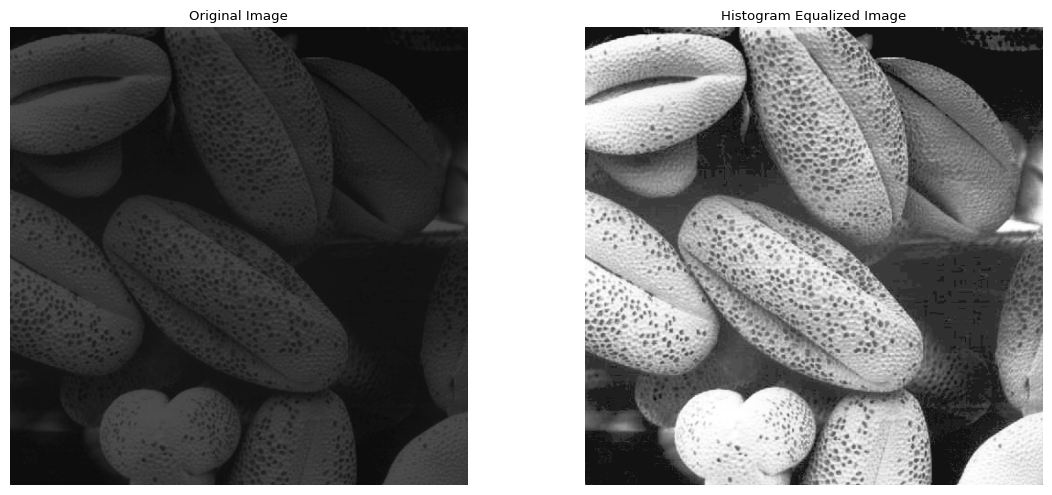

In [212]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img5, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(img5_eq, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Histogram Equalized Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

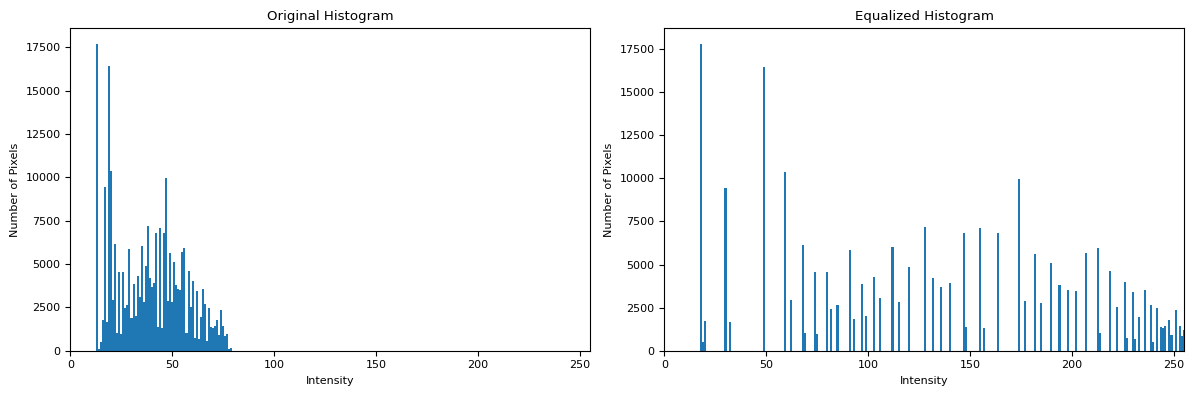

In [213]:
x = np.arange(256)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, hist, width=1)
axes[0].set_title("Original Histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Number of Pixels")
axes[0].set_xlim(0, 255)

axes[1].bar(x, hist_equalized, width=1)
axes[1].set_title("Equalized Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Number of Pixels")
axes[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

Histogram equalization spreads out the pixel values more evenly, especially when they were previously packed into a smaller range of intensities. 

However, this does not mean that every histogram bin will be filled or that every bin will have the same frequency. It only gives a rough equalization of the intensity distribution.